In [37]:
import pandas as pd
final_df = pd.read_csv('/Users/ozgeyavuz/synthbuster/dalle2/base_df.csv')
final_df2 = pd.read_csv('/Users/ozgeyavuz/synthbuster/midjourney-v5/base_df.csv')
final_df3 = pd.read_csv('/Users/ozgeyavuz/synthbuster/stable-diffusion-1-4/base_df.csv')
# Add model labels
final_df['model'] = 'dalle2'
final_df2['model'] = 'midjourney-v5'
final_df3['model'] = 'stable-diffusion-1-4'

# Combine all into one DataFrame
all_df = pd.concat([final_df, final_df2, final_df3], ignore_index=True)



In [38]:
import ast

# Safely convert string representation of list/tuple to actual Python object
all_df[['most_common_color_R', 'most_common_color_G', 'most_common_color_B']] = all_df['most_common_color'].apply(lambda x: pd.Series(ast.literal_eval(x)[0]))
all_df[['least_common_color_R', 'least_common_color_G', 'least_common_color_B']] = all_df['least_common_color'].apply(lambda x: pd.Series(ast.literal_eval(x)[0]))
all_df = all_df.drop(columns=['most_common_color', 'least_common_color'])
all_df.head()
#most common percentage
all_df[['most_common_percentage_1', 'most_common_percentage_2', 'most_common_percentage_3']] = all_df['most_common_percentage'].apply(lambda x: pd.Series(ast.literal_eval(x)))
all_df[['least_common_percentage_1', 'least_common_percentage_2', 'least_common_percentage_3']] = all_df['least_common_percentage'].apply(lambda x: pd.Series(ast.literal_eval(x)))
all_df = all_df.drop(columns=['most_common_percentage', 'least_common_percentage'])     
all_df.head()

,image,prompt,avg_brightness,max_brightness,min_brightness,contrast,avg_saturation,max_saturation,min_saturation,horizontal_symmetry,...,most_common_color_B,least_common_color_R,least_common_color_G,least_common_color_B,most_common_percentage_1,most_common_percentage_2,most_common_percentage_3,least_common_percentage_1,least_common_percentage_2,least_common_percentage_3
0,/Users/ozgeyavuz/synthbuster/dalle2/r17fe8532t...,r17fe8532t,133.124648,255.0000,0.0000,71.515001,38.989592,255.0,0.0,0.307190,...,214,226,226,217,0.10223,0.09489,0.09089,0.0001,0.0001,0.0001
1,/Users/ozgeyavuz/synthbuster/dalle2/r0648cff8t...,r0648cff8t,115.525865,255.0000,3.5748,57.524662,55.867724,255.0,0.0,0.121212,...,255,168,159,156,0.02375,0.01392,0.01383,0.0001,0.0001,0.0001
2,/Users/ozgeyavuz/synthbuster/dalle2/r1c243af7t...,r1c243af7t,142.339941,255.0000,0.8504,51.571350,99.460009,255.0,0.0,0.052151,...,223,141,120,39,0.02317,0.02241,0.02203,0.0001,0.0001,0.0001
3,/Users/ozgeyavuz/synthbuster/dalle2/r1800ab47t...,r1800ab47t,94.856203,254.5748,0.0000,47.815381,92.816821,255.0,0.0,0.155678,...,10,175,152,84,0.00973,0.00896,0.00868,0.0001,0.0001,0.0001
4,/Users/ozgeyavuz/synthbuster/dalle2/r09d5cb41t...,r09d5cb41t,144.620833,244.6070,17.0458,42.049943,109.927796,255.0,0.0,0.260665,...,152,146,135,128,0.02966,0.02937,0.02861,0.0001,0.0001,0.0001


In [39]:
all_df = all_df.drop(columns=['least_common_percentage_1','least_common_percentage_2','least_common_percentage_3'])


In [40]:
# Step 0: Imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score


X = all_df.drop(columns=['image','prompt','model'])
y = all_df['model']

# Step 2: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Use Random Forest for feature selection (RFE)
rf_classifier = RandomForestClassifier(random_state=42)
selector = RFE(rf_classifier, n_features_to_select=10)
selector = selector.fit(X_train, y_train)

# Step 4: Get selected features
selected_features = X_train.columns[selector.support_]
print("Selected features:", selected_features)

# Step 5: Filter datasets by selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]




Selected features: Index(['avg_brightness', 'min_brightness', 'contrast', 'edge_density',
       'whitespace_ratio', 'most_common_color_R', 'most_common_color_G',
       'most_common_color_B', 'most_common_percentage_1',
       'most_common_percentage_2'],
      dtype='object')


Epoch 1/500


/Users/ozgeyavuz/synthbuster/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3856 - loss: 1.0973 - val_accuracy: 0.5567 - val_loss: 0.9769 - learning_rate: 2.0000e-04
Epoch 2/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4658 - loss: 1.0212 - val_accuracy: 0.5817 - val_loss: 0.9149 - learning_rate: 2.0000e-04
Epoch 3/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5210 - loss: 0.9677 - val_accuracy: 0.6117 - val_loss: 0.8699 - learning_rate: 2.0000e-04
Epoch 4/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5552 - loss: 0.9315 - val_accuracy: 0.6200 - val_loss: 0.8350 - learning_rate: 2.0000e-04
Epoch 5/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5720 - loss: 0.8938 - val_accuracy: 0.6500 - val_loss: 0.8064 - learning_rate: 2.0000e-04
Epoch 6/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6135 - loss: 0.8774 - val_accuracy: 0.6617 - val_loss: 0.7872 - learning_rate: 2.0000e-04
Epoch 7/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6139 - loss: 0.86

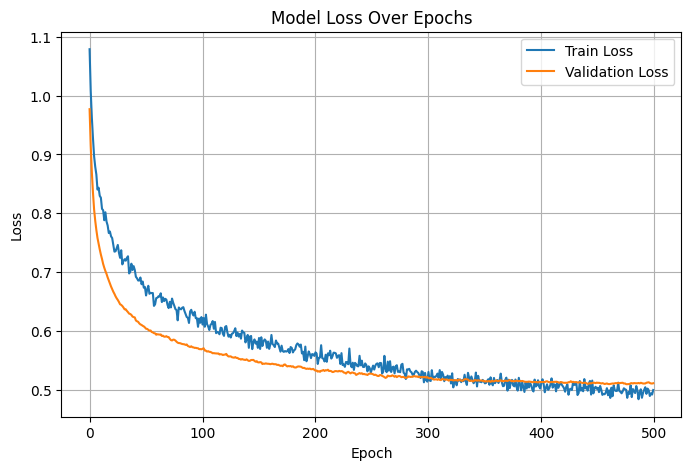

In [59]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau


# 1. Prepare data
X = X[selected_features]
y = all_df['model'].values

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# 2. Build MLP model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.7,   # reduce LR by this factor
    patience=20,   # after 5 epochs with no improvement
    min_lr=1e-6,  # don't go below this LR
    verbose=1
)



model.compile(
    optimizer=Adam(learning_rate=2e-4),  # Try 1e-3, 1e-4, or use learning rate scheduler
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train
history = model.fit(X_train_scaled, y_train_cat,
                    validation_data=(X_test_scaled, y_test_cat),
                    epochs=500,
                    batch_size=64,
                    callbacks=[ reduce_lr])

# 5. Evaluate
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

# Predictions and detailed report
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



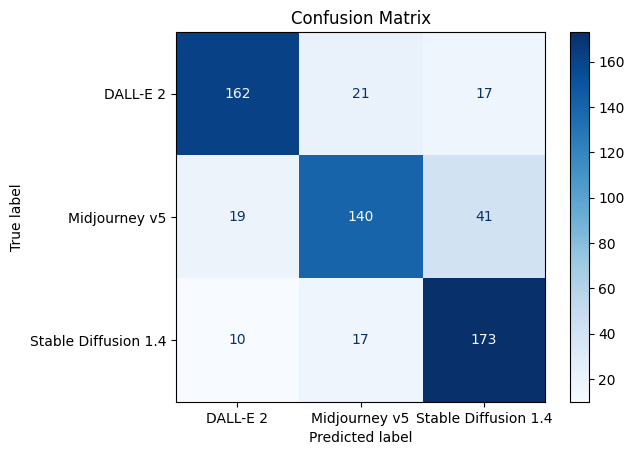

In [65]:
from sklearn.metrics import  ConfusionMatrixDisplay

class_names = ['DALL-E 2', 'Midjourney v5', 'Stable Diffusion 1.4']

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=class_names,
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.show()


In [42]:
# from pytorch_tabnet.tab_model import TabNetClassifier
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder


# # Assuming your full DataFrame is `all_df`
# # and target column is 'model'
# X = all_df.drop(columns=['image', 'prompt', 'model'])
# y = all_df['model']

# # Convert categorical target labels to integers (TabNet needs numeric labels)
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

# # Split into train/test (optional, for evaluation)
# X_train, X_test, y_train, y_test = train_test_split(
#     X.values,        # convert DataFrame to numpy array
#     y_encoded,       # encoded labels
#     test_size=0.2,
#     random_state=42,
#     stratify=y_encoded
# )

# clf = TabNetClassifier()


# clf.fit(
#     X_train, y_train,
#     max_epochs=600,
#     patience=10,
#     batch_size=256,
#     virtual_batch_size=128,
#     num_workers=0,
#     drop_last=False
# )

# # Predictions
# y_pred = clf.predict(X_test)

# from sklearn.metrics import accuracy_score
# print("Test Accuracy:", accuracy_score(y_test, y_pred))
